In [10]:
from scipy.stats import circmean
from astropy.stats import rayleightest
from scipy.stats import rayleigh
from lfp.lfp_analysis.LFP_collection import LFPCollection
import lfp.lfp_analysis.plotting as lfplt
import lfp.lfp_analysis.event_extraction as ee
import spike.spike_analysis.population_analysis as population_analysis
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.spike_collection as sc
import spike.spike_analysis.spike_recording as recording
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import hilbert
from scipy.stats import sem
def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))

In [9]:
TIMEBIN = 1
IGNORE_FREQ = 0.5
SMOOTHING_WINDOW = None
only_subjects_spike = sc.SpikeCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\only_subjects_spike_collection\spike_collection.json")
only_subjects_spike.analyze(timebin = TIMEBIN, ignore_freq=IGNORE_FREQ, smoothing_window=SMOOTHING_WINDOW)

only_subjects_lfp = LFPCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Only_Subjects (phase 5)\lfp_data\lfp_collection.json")

All set to analyze


In [11]:
beh_dict = unpickle_this(r"pilot2/only_subjects/behavior_dict_by_frames.pkl")
for rec in only_subjects_lfp.recordings:
    rec.set_event_dict(beh_dict[rec.name])

In [12]:
target_dict = {'1.1': ['BLA'],
              '1.2': ['NAc'],
              '1.3': ['BLA'],
              '2.1': [],
              '2.2': ['vHPC'],
              '2.3': ['mPFC', 'vHPC'],
              '2.4': ['BLA','MD'],
              '3.1': [],
              '3.2': [],
              '3.3': ['NAc', 'MD', 'vHPC'],
              '4.1': [],
              '4.4': ['NAc']}
only_subjects_lfp.exclude_regions(target_dict)

only_subjects_lfp.interpolate()

In [13]:
in_out_dict = unpickle_this("pilot2/only_subjects/ins_outs_dict_seconds.pkl")

In [17]:
in_out_dict

{'11_12_23_24': {'11_12_23_24.1.csv': [array([ 608.3966, 1212.0121, 1812.5787]),
   array([1205.98695, 1805.0257 ])],
  '11_12_23_24.2.csv': [array([ 603.061  , 1213.398  , 1813.20235]),
   array([1206.12215, 1804.54065])]},
 '11_13_21_22': {'11_13_21_22.1.csv': [array([ 610.6833 , 1231.1371 , 1869.60725]),
   array([1228.57325, 1865.9347 ])],
  '11_13_21_22.2.csv': [array([ 602.71455, 1235.4333 , 1874.94285]),
   array([1222.7526 , 1859.00535])]},
 '21_22_41_44': {'21_22_41_44.1.csv': [array([ 613.52435, 1240.49175, 1862.69765]),
   array([1235.50265, 1847.0176 ])],
  '21_22_41_44.2.csv': [array([ 605.9021 , 1243.74855, 1858.86675]),
   array([1229.95915, 1853.46185])]},
 '23_24_31_32': {'23_24_31_32.1.csv': [array([ 606.87215, 1243.26345, 1821.7947 ]),
   array([1234.11675, 1805.58005])],
  '23_24_31_32.2.csv': [array([ 608.95095, 1242.22405, 1817.15205]),
   array([1235.01755, 1814.31105])]}}

In [26]:

epoch_pairs = {                                                                                                                                                                                                                                                         
      '23_24_31_32.1': [('2.3', '3.2'), ('2.3', '3.1'), ('2.3', '2.4')],                                                                                                                                                                                                  
      '23_24_31_32.2': [('2.4', '3.1'), ('2.4', '3.2'), ('3.1', '3.2')],                                                                                                                                                                                                  
      '21_22_41_44.1': [('2.1', '4.1'), ('2.1', '2.2'), ('4.1', '2.2')],                                                                                                                                                                                                  
      '21_22_41_44.2': [('2.2', '4.4'), ('4.1', '4.4'), ('4.4', '2.1')],                                                                                                                                                                                                  
      '11_13_21_22.1': [('1.3', '2.1'), ('1.1', '1.3'), ('1.1', '2.1')],                                                                                                                                                                                                  
      '11_13_21_22.2': [('1.1', '2.2'), ('2.1', '2.2'), ('1.3', '2.2')],                                                                                                                                                                                                  
      '11_12_23_24.1': [('1.1', '1.2'), ('1.1', '2.4'), ('2.3', '1.1')],                                                                                                                                                                                                  
      '11_12_23_24.2': [('2.3', '2.4'), ('1.2', '2.3'), ('1.2', '2.4')],                                                                                                                                                                                                  
  } 

order_dict = {'11_12_23_24': {'cagemate': 1, 'novel': 2, 'familiar': 3},                                                                                                                                                                                                
            '11_13_21_22': {'novel': 1, 'cagemate': 2, 'familiar': 3},
            '21_22_41_44': {'familiar': 1, 'cagemate': 2, 'novel': 3},                                                                                                                                                                                                
            '23_24_31_32': {'novel': 1, 'familiar': 2, 'cagemate': 3}}

# Step 1: map group to order string (e.g. '11_12_23_24' -> 'CNF')
# order_dict tells us which position each condition is in, sort by position to get the string
group_to_order = {}
for group, conditions in order_dict.items():
    order_str = ''.join([k[0].upper() for k, v in sorted(conditions.items(), key=lambda x: x[1])])
    group_to_order[group] = order_str

print(group_to_order)
# {'11_12_23_24': 'CNF', '11_13_21_22': 'NCF', '21_22_41_44': 'FCN', '23_24_31_32': 'NFC'}

# Step 2: invert so we can look up by order string
order_to_group = {v: k for k, v in group_to_order.items()}
print(order_to_group)
# {'CNF': '11_12_23_24', 'NCF': '11_13_21_22', 'FCN': '21_22_41_44', 'NFC': '23_24_31_32'}
epoch_map_dict = {}
for rec_name in beh_dict.keys():
    subject = rec_name.split('_')[0]
    order   = rec_name.split('_')[1]
    subject_dot = f"{subject[0]}.{subject[1]}"
    group = order_to_group[order]
    condition_positions = order_dict[group]
    
    epoch_map_dict[rec_name] = {}
    
    for condition, position in condition_positions.items():
        epoch_idx = position - 1
        
        epoch_file = None
        for csv_name in in_out_dict[group].keys():
            suffix = csv_name.split('.')[1]
            pairs = epoch_pairs[f"{group}.{suffix}"]
            pair_at_epoch = pairs[epoch_idx]
            if subject_dot in pair_at_epoch:
                epoch_file = csv_name
                break
        
        if epoch_file is None:
            print(f"WARNING: no epoch file found for {rec_name} | {condition}")
            continue
        
        mouse_in, mouse_out = in_out_dict[group][epoch_file]
        epoch_map_dict[rec_name][condition] = [mouse_in[epoch_idx], mouse_out[epoch_idx] if epoch_idx < len(mouse_out) else None]

# inspect
for rec, conditions in epoch_map_dict.items():
    print(f"\n{rec}:")
    for condition, times in conditions.items():
        print(f"  {condition}: in={times[0]:.2f}, out={times[1]}")

{'11_12_23_24': 'CNF', '11_13_21_22': 'NCF', '21_22_41_44': 'FCN', '23_24_31_32': 'NFC'}
{'CNF': '11_12_23_24', 'NCF': '11_13_21_22', 'FCN': '21_22_41_44', 'NFC': '23_24_31_32'}

23_NFC_merged.rec:
  novel: in=606.87, out=1234.1167500000001
  familiar: in=1243.26, out=1805.58005
  cagemate: in=1821.79, out=None

32_NFC_merged.rec:
  novel: in=606.87, out=1234.1167500000001
  familiar: in=1242.22, out=1814.3110499999998
  cagemate: in=1817.15, out=None

31_NFC_merged.rec:
  novel: in=608.95, out=1235.01755
  familiar: in=1243.26, out=1805.58005
  cagemate: in=1817.15, out=None

24_NFC_merged.rec:
  novel: in=608.95, out=1235.01755
  familiar: in=1242.22, out=1814.3110499999998
  cagemate: in=1821.79, out=None

21_FCN_merged.rec:
  familiar: in=613.52, out=1235.50265
  cagemate: in=1240.49, out=1847.0176000000001
  novel: in=1858.87, out=None

41_FCN_merged.rec:
  familiar: in=613.52, out=1235.50265
  cagemate: in=1243.75, out=1853.4618500000001
  novel: in=1862.70, out=None

22_FCN_merg

{'23_NFC_merged.rec': {'novel': [np.float64(606.87215),
   np.float64(1234.1167500000001)],
  'familiar': [np.float64(1243.26345), np.float64(1805.58005)],
  'cagemate': [np.float64(1821.7947), None]},
 '32_NFC_merged.rec': {'novel': [np.float64(606.87215),
   np.float64(1234.1167500000001)],
  'familiar': [np.float64(1242.2240499999998), np.float64(1814.3110499999998)],
  'cagemate': [np.float64(1817.1520500000001), None]},
 '31_NFC_merged.rec': {'novel': [np.float64(608.95095),
   np.float64(1235.01755)],
  'familiar': [np.float64(1243.26345), np.float64(1805.58005)],
  'cagemate': [np.float64(1817.1520500000001), None]},
 '24_NFC_merged.rec': {'novel': [np.float64(608.95095),
   np.float64(1235.01755)],
  'familiar': [np.float64(1242.2240499999998), np.float64(1814.3110499999998)],
  'cagemate': [np.float64(1821.7947), None]},
 '21_FCN_merged.rec': {'familiar': [np.float64(613.52435),
   np.float64(1235.50265)],
  'cagemate': [np.float64(1240.49175), np.float64(1847.0176000000001)],

In [27]:
def calculate_phase_at_frequencies(signal_data, fs, freq_bands):
    """
    Calculate phase at different frequency bands using Hilbert transform
    
    Parameters:
    -----------
    signal_data : array
        Input time series data
    fs : float
        Sampling frequency in Hz
    freq_bands : list of tuples
        List of (low_freq, high_freq) defining frequency bands of interest
        
    Returns:
    --------
    phases : dict
        Dictionary with frequency bands as keys and phase arrays as values
    """
    phases = {}
    
    for low_freq, high_freq in freq_bands:
        # Design a bandpass filter
        nyquist = fs / 2
        low = low_freq / nyquist
        high = high_freq / nyquist
        b, a = signal.butter(2, [low_freq, high_freq], fs = fs, btype='bandpass')
        
        # Apply the filter
        filtered_signal = signal.filtfilt(b, a, x=signal_data)
        
        # Apply Hilbert transform to get analytic signal
        analytic_signal = hilbert(filtered_signal)
        
        # Extract instantaneous phase
        instantaneous_phase = np.angle(analytic_signal)
        
        # Store in dictionary
        band_name = f"{low_freq}-{high_freq}Hz"
        phases[band_name] = instantaneous_phase
    
    return phases



In [28]:
rec_phase_dict = {}
for recording in only_subjects_lfp.recordings:
    region_dict = {}
    for region in range(recording.traces.shape[1]):
        traces = recording.traces[:,region]
        phase_dict = calculate_phase_at_frequencies(traces, 1000, [(4,12), (12,30), (30,59), (59,80)])
        region_dict[recording.brain_region_dict.inverse[region]] = phase_dict
    rec_phase_dict[recording.name] = region_dict

In [33]:
epoch_map_dict['11_CNF_merged.rec']['cagemate']

[np.float64(608.3966), np.float64(1205.98695)]

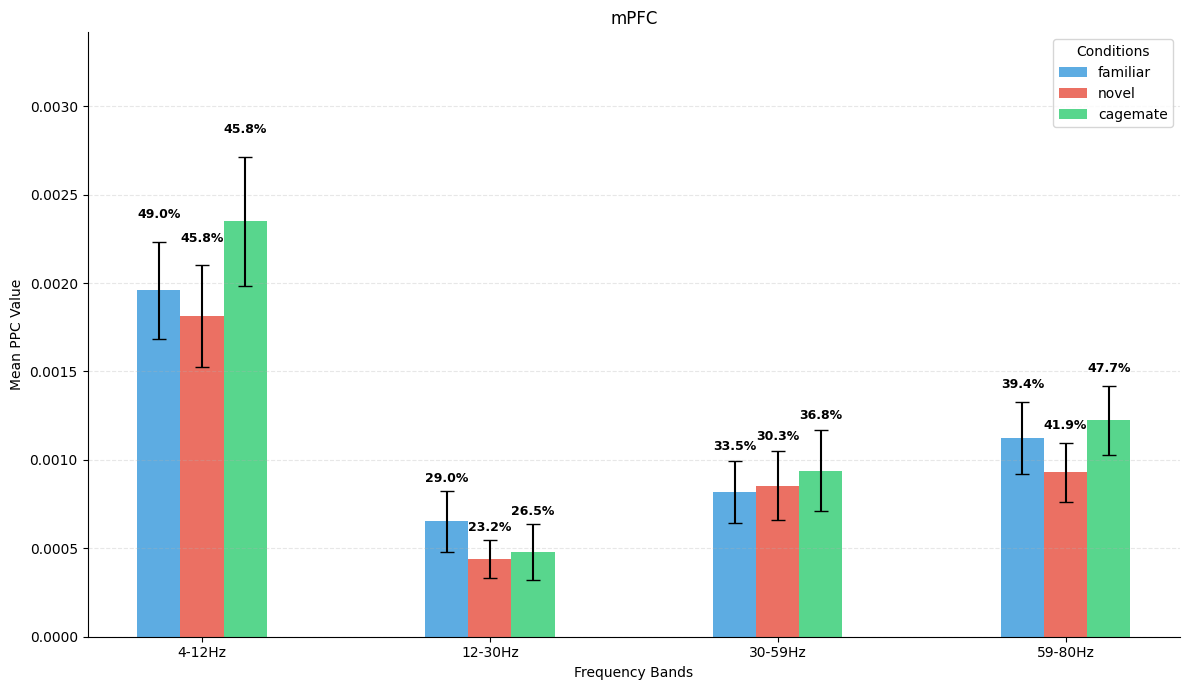

KeyboardInterrupt: 

In [37]:
    
# Assuming we have these variables defined:
# cell_ts_off - spike timestamps
# Ph_OFF - a function that returns phases at given timestamps
# LFPinsoff - indices of LFP at spike times
# unit - current unit being analyzed
# PPCthetabla - array to store results
events = ['familiar', 'novel', 'cagemate']
freq_bands = ['4-12Hz', '12-30Hz', '30-59Hz', '59-80Hz']
for region in only_subjects_lfp.brain_region_dict.keys():
    seg_ppc_dict = {}
    for event in events:
        ppc_dict = {}
        for freq_band in freq_bands:
            PPCs = []
            rayleighs = []
            for recording in only_subjects_spike.recordings:
                for unit, spike_trains in recording.unit_spiketrains.items():
                    times = epoch_map_dict[recording.name][event]
                    values = rec_phase_dict[recording.name][region][freq_band]
                    try:
                        seg_spike_train = spike_trains[int(times[0])*1000:int(times[1])*1000]
                        seg_lfp_phase = values[int(times[0])*1000:int(times[1])*1000]
                    except (IndexError, ValueError, TypeError):
                        seg_spike_train = spike_trains[int(times[0])*1000:int(spike_trains.shape[0])]
                        seg_lfp_phase = values[int(times[0])*1000:int(spike_trains.shape[0])]
                    if seg_spike_train.shape[0] != seg_lfp_phase.shape[0]:
                        shorter_len = min(seg_spike_train.shape[0], seg_lfp_phase.shape[0])
                        seg_spike_train = seg_spike_train[:shorter_len]
                        seg_lfp_phase = seg_lfp_phase[:shorter_len]
                                    
                    if sum(seg_spike_train) > 100:
                        # Extract spike phases
                        mask = seg_spike_train.astype(bool)
                        spike_phases = seg_lfp_phase[mask]
                

                        # Create matrices for all pairwise comparisons
                        temp1 = np.tile(spike_phases, (len(spike_phases), 1))
                        temp2 = temp1.T
                        # Calculate absolute circular distance between all pairs
                        
                        r = np.abs(np.angle(np.exp(1j*temp1)/np.exp(1j*temp2)))
                        # Create identity matrix with same dimensions
                        add_nans = np.eye(temp1.shape[0])
                        
                        # Replace ones with NaN
                        add_nans[add_nans == 1] = np.nan
                        
                        # Add NaNs to diagonal
                        r = r + add_nans
                        
                        # Calculate PPC
                        PPC = (np.pi - 2 * np.nanmean(np.nanmean(r))) / np.pi
                        p = rayleightest(spike_phases)
                        rayleighs.append(p)
                        # fig, ax = plt.subplots(1, 1)
                        # r = rayleigh.rvs(spike_phases)
                        # ax.hist(spike_phases, density=True, bins=20, histtype='stepfilled', alpha=0.2)
                        # ax.set_title(f'{unit}: PPC:{PPC}, p = {p}')
                        # plt.show()
                    else:
                        # Not enough spikes
                        rayleighs.append(np.nan)
                        PPC= np.nan
                    PPCs.append(PPC)
            ppc_array = np.array(PPCs)
            ppc_mean = np.nanmean(ppc_array)
            ppc_sem = sem(ppc_array, nan_policy='omit')
            percent_sig = np.sum(np.array(rayleighs) < .05)/len(rayleighs)
            ppc_dict[freq_band] = [ppc_mean, ppc_sem, percent_sig]
        seg_ppc_dict[event] = ppc_dict

    inner_keys = list(next(iter(seg_ppc_dict.values())).keys())
    outer_keys = list(seg_ppc_dict.keys())

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(12, 7))

    # Define bar properties
    bar_width = 0.15
    opacity = 0.8
    index = np.arange(len(inner_keys))
    colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green

    # Plot grouped bars for each outer key (group)
    for i, outer_key in enumerate(outer_keys):
        # Extract data for this group
        group_data = seg_ppc_dict[outer_key]
        means = [group_data[key][0] for key in inner_keys]
        sems = [group_data[key][1] for key in inner_keys]
        percentages = [group_data[key][2]*100 for key in inner_keys]
        
        # Calculate position for this group's bars
        position = index + (i - len(outer_keys)/2 + 0.5) * bar_width
        
        # Plot the bars for this group
        bars = ax.bar(position, means, bar_width, 
                    yerr=sems, capsize=5,
                    alpha=opacity, color=colors[i], 
                    label=outer_key)
        
        # Add percentage labels above each bar
        for j, bar in enumerate(bars):
            height = bar.get_height()
            label_height = height + sems[j] + max([seg_ppc_dict[k][inner_keys[j]][0] 
                                                for k in outer_keys]) * 0.05
            ax.text(bar.get_x() + bar.get_width()/2., label_height,
                    f'{percentages[j]:.1f}%', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Add labels, title and legend
    ax.set_xlabel('Frequency Bands')
    ax.set_ylabel('Mean PPC Value')
    ax.set_title(f'{region}')
    ax.set_xticks(index)
    ax.set_xticklabels(inner_keys)
    ax.legend(title='Conditions')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add some extra space for the labels
    plt.ylim(top=plt.ylim()[1] * 1.2)

    # Add a grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
if sum(seg_spike_train) > 100:
    mask = seg_spike_train.astype(bool)
    spike_phases = seg_lfp_phase[mask]
    n = len(spike_phases)
    
    # Vectorized closed-form PPC (Vinck et al. 2010)
    z = np.exp(1j * spike_phases)
    R = np.abs(np.sum(z))**2
    PPC = (R - n) / (n * (n - 1))

In [ ]:
if sum(seg_spike_train) > 100:
    # Extract spike phases
    mask = seg_spike_train.astype(bool)
    spike_phases = seg_lfp_phase[mask]


    # Create matrices for all pairwise comparisons
    temp1 = np.tile(spike_phases, (len(spike_phases), 1))
    temp2 = temp1.T
    # Calculate absolute circular distance between all pairs
    r = np.abs(np.angle(np.exp(1j*temp1)/np.exp(1j*temp2)))
    # Create identity matrix with same dimensions
    add_nans = np.eye(temp1.shape[0])
    # Replace ones with NaN
    add_nans[add_nans == 1] = np.nan
    # Add NaNs to diagonal
    r = r + add_nans
    # Calculate PPC
    PPC = (np.pi - 2 * np.nanmean(np.nanmean(r))) / np.pi
    p = rayleightest(spike_phases)
    rayleighs.append(p)